# Ground-state energy versus charge distance, comparing SKQD, random, and PT

Result from December 2025

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import h5py
import jax
from skqd_z2lgt.parameters import Parameters
from skqd_z2lgt.tasks.common import make_dual_lattice
from skqd_z2lgt.extensions import extensions
from skqd_z2lgt.sqd import sqd

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
jax.config.update('jax_enable_x64', True)

data_dir = Path('/mnt/ssh/miyabi_p14000/data')

In [2]:
init = {}
rnd = {}
rcv = {}
dmrg = {}
noqkd = {}

for pkgtag in [
    'q_20_21_K_1_dt_01',
    'q_20_22_K_1_dt_01',
    'q_20_23_K_1_dt_01',
    'q_20_23_K_1_dt_005',
    'q_20_24_K_1_dt_005',
    'q_20_24_K_1_dt_002'
]:
    with h5py.File(data_dir / f'full156_{pkgtag}/dmrg.h5') as source:
        dmrg[pkgtag] = source['energy'][()]
    with h5py.File(data_dir / f'full156_{pkgtag}/skqd_init.h5') as source:
        init[pkgtag] = source['energy'][()]
    with h5py.File(data_dir / f'full156_{pkgtag}/skqd_rnd.h5') as source:
        rnd[pkgtag] = source['energy'][()]
    with h5py.File(data_dir / f'full156_{pkgtag}/skqd_rcv.h5') as source:
        rcv[pkgtag] = source['energy'][()]

    with open(data_dir / f'full156_{pkgtag}/parameters.json', 'r', encoding='utf-8') as src:
        params = Parameters.model_validate_json(src.read())

    dual_lattice = make_dual_lattice(params)
    hamiltonian = dual_lattice.make_hamiltonian(params.lgt.plaquette_energy)
    states = extensions['perturbation_2q'](np.empty((0, 64), dtype=np.uint8), dual_lattice)
    noqkd[pkgtag] = sqd(hamiltonian, states)[0]

Text(0.5, 0, 'Charge distance')

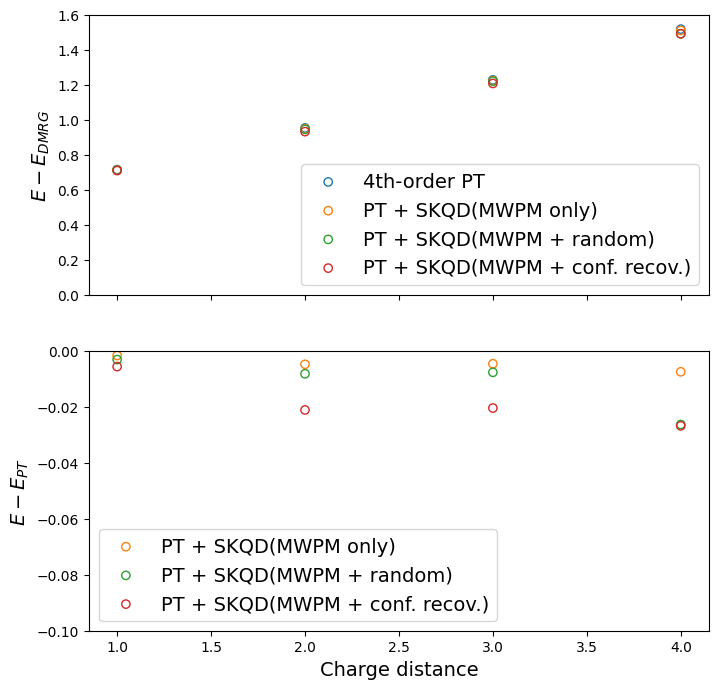

In [20]:
distances = np.arange(1, 5)
main_series = [
    'q_20_21_K_1_dt_01',
    'q_20_22_K_1_dt_01',
    'q_20_23_K_1_dt_01',
    'q_20_24_K_1_dt_005'
]
fig, axs = plt.subplots(2, sharex=True, figsize=(8, 8))
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
axs[0].scatter(distances, [noqkd[pkgtag] - dmrg[pkgtag] for pkgtag in main_series], label='4th-order PT',
               marker='o', facecolors='none', edgecolors=colors[0])
axs[0].scatter(distances, [init[pkgtag] - dmrg[pkgtag] for pkgtag in main_series], label='PT + SKQD(MWPM only)',
               marker='o', facecolors='none', edgecolors=colors[1])
axs[0].scatter(distances, [rnd[pkgtag] - dmrg[pkgtag] for pkgtag in main_series], label='PT + SKQD(MWPM + random)',
               marker='o', facecolors='none', edgecolors=colors[2])
axs[0].scatter(distances, [rcv[pkgtag] - dmrg[pkgtag] for pkgtag in main_series], label='PT + SKQD(MWPM + conf. recov.)',
               marker='o', facecolors='none', edgecolors=colors[3])
axs[0].set_ylim(0., 1.6)
axs[0].legend(fontsize=14);
axs[0].set_ylabel(r'$E - E_{DMRG}$', fontsize=14)
axs[1].scatter(distances, [-noqkd[pkgtag] + init[pkgtag] for pkgtag in main_series], label='PT + SKQD(MWPM only)',
               marker='o', facecolors='none', edgecolors=colors[1])
axs[1].scatter(distances, [-noqkd[pkgtag] + rnd[pkgtag] for pkgtag in main_series], label='PT + SKQD(MWPM + random)',
               marker='o', facecolors='none', edgecolors=colors[2])
axs[1].scatter(distances, [-noqkd[pkgtag] + rcv[pkgtag] for pkgtag in main_series], label='PT + SKQD(MWPM + conf. recov.)',
               marker='o', facecolors='none', edgecolors=colors[3])
axs[1].set_ylim(-0.1, 0.)
axs[1].legend(fontsize=14);
axs[1].set_ylabel(r'$E - E_{PT}$', fontsize=14)
axs[1].set_xlabel('Charge distance', fontsize=14)

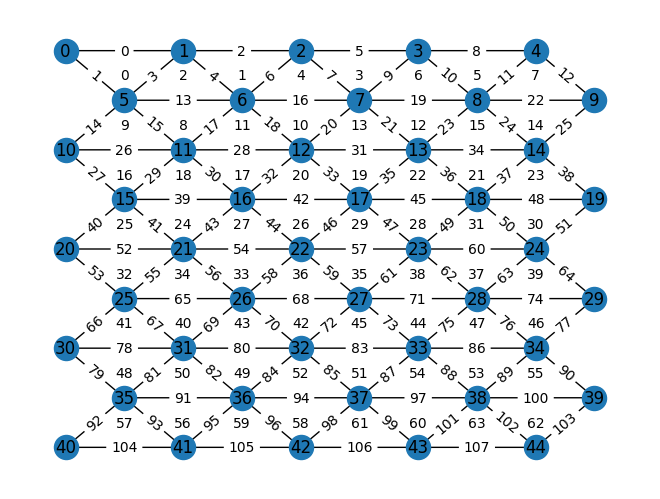

In [21]:
dual_lattice.primal.draw_graph();

In [19]:
result

(-105.7096176147461,
 array([0.8139549 +0.j, 0.06951161+0.j, 0.07266423+0.j, ...,
        0.        +0.j, 0.        +0.j, 0.        +0.j],
       shape=(679121,), dtype=complex64),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 1, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], shape=(679121, 64), dtype=uint8),
 <Compressed Sparse Row sparse array of dtype 'complex64'
 	with 6020305 stored elements and shape (679121, 679121)>)